<a href="https://colab.research.google.com/github/ethan-looooo/gasoline-tracker/blob/main/Official_Gas_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense


import random

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import seaborn as sns
from scipy import stats
from plotnine import *



In [ ]:
#Mounting Drive
from google.colab import drive
drive.mount('/content/drive/')
# Importing Datasets
merged_data = pd.read_csv("/content/drive/Shareddrives/MLSN Team 6/Datasets/Merged Data.csv")
merged_data

Mounted at /content/drive/


,Week #,Gas Week,Stock Closing Date,Past Week Gas,S&P 500,DOW J Oil,NYSE ARCA,Current Gas
0,1,12/23/2024,12/20/2024,3.137,"4,754.63","6,580.01","1,702.89",3.145
1,2,12/16/2024,12/13/2024,3.131,"4,719.19","6,970.53","1,821.55",3.137
2,3,12/9/2024,12/6/2024,3.156,"4,604.37","7,096.40","1,851.75",3.131
3,4,12/2/2024,11/29/2024,3.166,"4,594.63","7,438.56","1,935.28",3.156
4,5,11/25/2024,11/22/2024,3.168,"4,559.34","7,582.15","1,973.56",3.166
...,...,...,...,...,...,...,...,...
255,256,02/03/2020,01/31/2020,2.595,"3,225.52","4,070.79","1,115.14",2.546
256,257,01/27/2020,01/24/2020,2.625,"3,295.47","4,312.31","1,197.18",2.595
257,258,01/20/2020,01/17/2020,2.657,"3,329.62","4,524.04","1,253.75",2.625
258,259,01/13/2020,01/10/2020,2.665,"3,265.35","4,577.32","1,273.29",2.657


In [ ]:
#Type changing to strings
merged_data = merged_data.convert_dtypes()

# Removing commas, converting to floats
merged_data['S&P 500'] = merged_data['S&P 500'].str.replace(',', '')
merged_data['S&P 500'] = merged_data['S&P 500'].astype(float)
merged_data['DOW J Oil'] = merged_data['DOW J Oil'].str.replace(',', '')
merged_data['DOW J Oil'] = merged_data['DOW J Oil'].astype(float)
merged_data['NYSE ARCA'] = merged_data['NYSE ARCA'].str.replace(',', '')
merged_data['NYSE ARCA'] = merged_data['NYSE ARCA'].astype(float)

#Date Time Conversions
merged_data[' Gas Week'] = pd.to_datetime(merged_data[' Gas Week'], format='%m/%d/%Y', errors='coerce')
merged_data['Stock Closing Date'] = pd.to_datetime(merged_data['Stock Closing Date'], format='%m/%d/%Y', errors='coerce')

In [ ]:
# Handling Outliers

Gas_lower = 1.8219999999999996
Gas_upper =  4.814

SP_Lower = 2686.6537500000004
SP_upper = 5755.403749999999

no_outliers = merged_data.copy()

for index, values in no_outliers['Current Gas'].items():
  if (values < Gas_lower ):
    print(no_outliers.at[index, 'Current Gas'])
    no_outliers.at[index, 'Current Gas'] = Gas_lower
    print("New vlaue is ", no_outliers.at[index, 'Current Gas'])
  elif (values > Gas_upper):
    no_outliers.at[index, 'Current Gas'] = Gas_upper

for index,values in no_outliers['Past Week Gas'].items():
  if (values < Gas_lower ):
    no_outliers.at[index, 'Past Week Gas'] = Gas_lower

  elif (values > Gas_upper):
    no_outliers.at[index, 'Past Week Gas'] = Gas_upper

for index,values in no_outliers['S&P 500'].items():
  if (values < SP_Lower ):
    no_outliers.at[index, 'S&P 500'] = SP_Lower
  elif (values > SP_upper):
    no_outliers.at[index, 'S&P 500'] = SP_upper

# Adding another row for 1 week and 2 week with no outlier data
no_outliers['2 Week past Gas'] = no_outliers['Current Gas'].shift(-1)
no_outliers['3 Week past Gas'] = no_outliers['Current Gas'].shift(-2)


no_outliers['2 Week past Gas'] = no_outliers['2 Week past Gas'].fillna(0)
no_outliers['3 Week past Gas'] = no_outliers['3 Week past Gas'].fillna(0)


# adding mean Feature for Oil Indices
no_outliers['DOW_NYSE_Avg'] = no_outliers[['DOW J Oil', 'NYSE ARCA']].mean(axis=1)


#Creating new csv "new_no_outliers"
no_outliers.to_csv('/content/drive/Shareddrives/MLSN Team 6/Datasets/new_no_outliers.csv', index=False)


In [ ]:
#Reading dataset
new_no_outlier = pd.read_csv("/content/drive/Shareddrives/MLSN Team 6/Datasets/new_no_outliers.csv")
new_no_outlier.head()

,Week #,Gas Week,Stock Closing Date,Past Week Gas,S&P 500,DOW J Oil,NYSE ARCA,Current Gas,2 Week past Gas,3 Week past Gas,DOW_NYSE_Avg
0,1,2024-12-23,2024-12-20,3.137,4754.63,6580.01,1702.89,3.145,3.137,3.131,4141.450
1,2,2024-12-16,2024-12-13,3.131,4719.19,6970.53,1821.55,3.137,3.131,3.156,4396.040
2,3,2024-12-09,2024-12-06,3.156,4604.37,7096.40,1851.75,3.131,3.156,3.166,4474.075
3,4,2024-12-02,2024-11-29,3.166,4594.63,7438.56,1935.28,3.156,3.166,3.168,4686.920
4,5,2024-11-25,2024-11-22,3.168,4559.34,7582.15,1973.56,3.166,3.168,3.176,4777.855


In [ ]:
#Setting Seed for Consistency
random.seed(80)
np.random.seed(80)
tf.random.set_seed(80)


# Defining Features vs Target
features = ['Past Week Gas', 'S&P 500', 'DOW J Oil', 'NYSE ARCA', 'DOW_NYSE_Avg', '2 Week past Gas', '3 Week past Gas']
target = 'Current Gas'
feature_data = new_no_outlier[features]
target_data = new_no_outlier[target]


# Scaling the Data
scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(feature_data)
scaled_target = target_scaler.fit_transform(target_data.values.reshape(-1, 1))
X = scaled_data
y = scaled_target


#80-20 Data Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


#Create Model
model = keras.models.Sequential()
model.add(Dense(units=4, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(units=4, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=500, batch_size=8, validation_split=0.2, verbose=1)


Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.4515 - val_loss: 0.0986
Epoch 2/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2062 - val_loss: 0.0138
Epoch 3/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0487 - val_loss: 0.0111
Epoch 4/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0106 - val_loss: 0.0254
Epoch 5/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0081 - val_loss: 0.0225
Epoch 6/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0069 - val_loss: 0.0181
Epoch 7/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0061 - val_loss: 0.0162
Epoch 8/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0054 - val_loss: 0.0149
Epoch 9/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0049 - val_loss: 0.0148
Epoch 10/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0047 - val_loss: 0.0148
Epoch 11/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0045 - val_loss: 0.0145
Epoch 12/500
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 

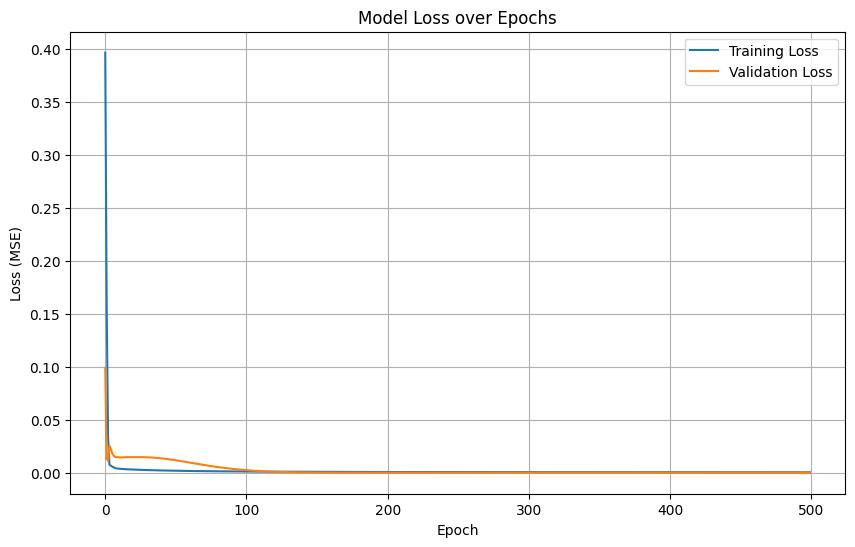

In [ ]:
#Plot Training History

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


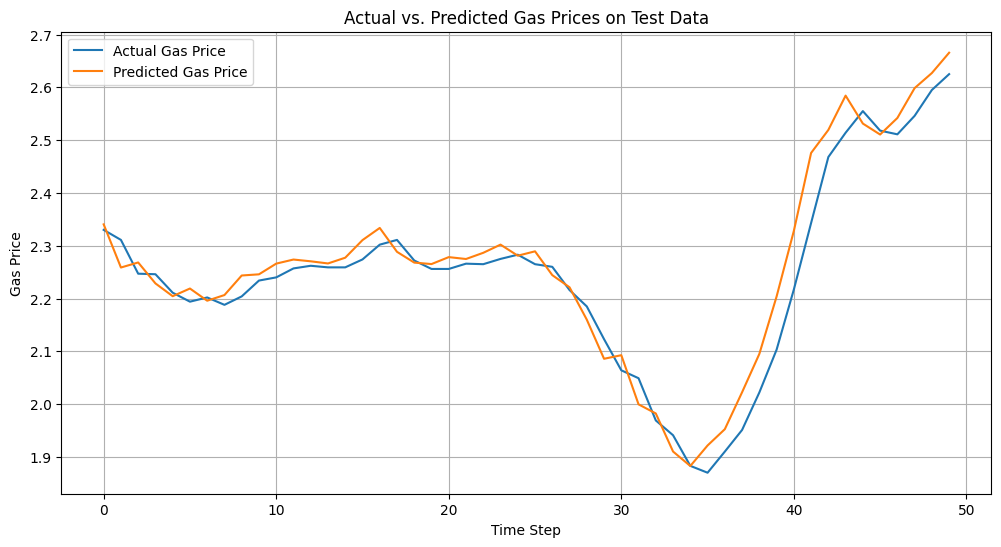

In [ ]:
#Comparative Graph


# Make predictions on the test set
predictions = model.predict(X_test)

# Inverse Transformation
predictions = target_scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = target_scaler.inverse_transform(y_test)

# Plot Actual vs. Predicted values
plt.figure(figsize=(12, 6))

plt.plot(y_test_actual[:50], label='Actual Gas Price')
plt.plot(predictions[:50], label='Predicted Gas Price')

plt.title('Actual vs. Predicted Gas Prices on Test Data')
plt.xlabel('Time Step')
plt.ylabel('Gas Price')
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
#Measuring Error


mae = mean_absolute_error(y_test_actual, predictions)
print(f"MAE: {mae}")

mse = mean_squared_error(y_test_actual, predictions)
print(f'MSE: {mse}')


MAE: 0.042666472856815026
MSE: 0.006412313234209418


In [ ]:
#Comparison Table

diffs = abs(predictions[:50].reshape(-1, 1) - y_test_actual[:50])

data = {
            "Test Predictions": predictions[:50].flatten(),
            "Test Actual Data": y_test_actual[:50].flatten(),
            "Difference": diffs.flatten()
        }

df = pd.DataFrame(data)

print(df)

    Test Predictions  Test Actual Data  Difference
0           2.340432             2.330    0.010432
1           2.258702             2.311    0.052298
2           2.268263             2.247    0.021263
3           2.228600             2.246    0.017400
4           2.204378             2.211    0.006622
5           2.218906             2.194    0.024906
6           2.195801             2.202    0.006199
7           2.206554             2.188    0.018554
8           2.243585             2.204    0.039585
9           2.245806             2.234    0.011806
10          2.266078             2.240    0.026078
11          2.273810             2.257    0.016810
12          2.270463             2.262    0.008463
13          2.266396             2.259    0.007396
14          2.277286             2.259    0.018286
15          2.310620             2.274    0.036620
16          2.333666             2.302    0.031666
17          2.288450             2.311    0.022550
18          2.268013           

In [ ]:
#Stock & Gas Data from the week of 6/26
#(sourced from Yahoo Finance, Market Watch, & the US Energy Information Administration)
data = {
    'Past Week Gas': [3.288],
    'S&P 500': [5911.69],
    'DOW J Oil': [6347.85],
    'NYSE ARCA': [1692.06],
    'DOW_NYSE_Avg': [4019.955],
    '2 Week past Gas': [3.302],
    '3 Week past Gas': [3.249]
}

In [ ]:
#Scaling
last_week_data = pd.DataFrame(data)
target_scaler = MinMaxScaler()
target_scaler.fit(new_no_outlier['Current Gas'].values.reshape(-1, 1))
scaled_last_week_data = scaler.transform(last_week_data)

#Making Prediction
prediction = model.predict(scaled_last_week_data)

#Descaling
predicted_gas_price = target_scaler.inverse_transform(prediction)


print(f"Predicted Upcoming Week's National Average Gas Price: ${predicted_gas_price[0][0]:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Upcoming Week's National Average Gas Price: $3.291


# Task
The task is to build a neural network model to predict the "Current Gas" price using the `new_no_outlier.csv` dataset. This involves loading the data, selecting features ('Past Week Gas', 'S&P 500', 'DOW J Oil', 'NYSE ARCA', 'DOW_NYSE_Avg', '2 Week past Gas', '3 Week past Gas') and the 'Current Gas' target, and scaling them using `MinMaxScaler`. The data will then be split into training and testing sets (80-20 split). A Keras Sequential model will be defined with two hidden Dense layers (4 units, 'relu' activation) and an output Dense layer (1 unit), compiled with the 'adam' optimizer and 'mse' loss, and trained for 500 epochs with a batch size of 8 and a 20% validation split. Finally, the model's performance will be evaluated using MAE, MSE, and plots of training history and actual vs. predicted values, and then used to predict the upcoming week's national average gas price based on new data provided for the week of 6/26.

## Load and Prepare Data

### Subtask:
Acknowledge that the dataset has been loaded, features and target selected, and data scaled.


The `new_no_outlier` dataset has been successfully loaded. The features (`'Past Week Gas'`, `'S&P 500'`, `'DOW J Oil'`, `'NYSE ARCA'`, `'DOW_NYSE_Avg'`, `'2 Week past Gas'`, `'3 Week past Gas'`) and the target (`'Current Gas'`) have been selected and scaled using `MinMaxScaler`. The scaled features are stored in `X` and scaled target in `y`.

## Split Data into Training and Testing Sets

### Subtask:
Describe how the scaled data is divided into training and testing sets, with an 80-20 split, to prepare for model training and evaluation.


The `X` (scaled features) and `y` (scaled target) datasets were successfully divided into training and testing sets. An 80-20 split ratio was applied, resulting in `X_train`, `y_train` for model training and `X_test`, `y_test` for evaluation.

## Define and Compile the Neural Network Model

### Subtask:
Explain the architecture of the Keras Sequential model: an input Dense layer with 4 units and 'relu' activation, a hidden Dense layer with 4 units and 'relu' activation, and an output Dense layer with 1 unit. Detail how the model is compiled using the 'adam' optimizer and 'mse' (mean squared error) loss function.


The neural network model is built using Keras's `Sequential` API, which allows for a linear stack of layers. The architecture is as follows:

1.  **Input Layer**: A `Dense` layer with `4` units and a `'relu'` (Rectified Linear Unit) activation function. The `input_shape` is dynamically set to `(X_train.shape[1],)`, which corresponds to the number of features in the training data. The ReLU activation function introduces non-linearity, allowing the model to learn complex patterns.

2.  **Hidden Layer**: Another `Dense` layer with `4` units and a `'relu'` activation function. This layer further processes the input from the previous layer.

3.  **Output Layer**: A final `Dense` layer with `1` unit. Since this is a regression task (predicting a continuous gas price), no activation function is specified, meaning it uses a linear activation by default. This layer outputs the predicted gas price.

### Model Compilation

The model is compiled with the following settings:

-   **Optimizer**: `'adam'`. Adam (Adaptive Moment Estimation) is an optimization algorithm that can be used instead of the classical stochastic gradient descent procedure to update network weights iterative based in training data.

-   **Loss Function**: `'mse'` (Mean Squared Error). MSE is a common loss function for regression problems, measuring the average of the squares of the errors. It calculates the sum of the squared differences between predicted and actual values, penalizing larger errors more heavily.

## Train the Model

### Subtask:
Outline the training process for the neural network, including the number of epochs (500), batch size (8), and the use of a 20% validation split to monitor performance during training.


The neural network model has already been trained using the `X_train` and `y_train` datasets. The training was conducted for 500 epochs, with a batch size of 8, and a 20% validation split to monitor performance. The training history, including loss and validation loss, is stored in the `history` object.

## Evaluate Model Performance

### Subtask:
Describe how predictions were made on the test set, how values were inverse transformed, the calculated MAE and MSE, and the generation of plots for training history and actual vs. predicted values.


### Model Evaluation Summary

1.  **Predictions on Test Set**: Predictions on the unseen test set were generated using the trained neural network model. These predictions are stored in the `predictions` variable.
2.  **Inverse Transformation**: Both the `predictions` and the actual `y_test` values (which were originally scaled during preprocessing) were inverse-transformed using the `target_scaler`. This step was crucial to revert them to their original scale, making them interpretable in terms of actual gas prices. The inverse-transformed actual values are stored in `y_test_actual`.
3.  **Error Metrics**: The Mean Absolute Error (MAE) and Mean Squared Error (MSE) were calculated using the inverse-transformed actual and predicted values. These metrics provide a quantitative measure of the model's accuracy, indicating the average magnitude of errors in the predictions.
4.  **Training History Plot**: The model's training history, specifically the training loss and validation loss across epochs, was visualized using `matplotlib.pyplot`. This plot helps in understanding the model's learning progress and identifying potential overfitting or underfitting.
5.  **Actual vs. Predicted Plot**: A comparative plot was generated showing the actual gas prices versus the predicted gas prices on the test data. This visualization allows for a direct comparison of the model's output against the true values, providing an intuitive assessment of its performance and ability to capture trends.

## Make Predictions on New Data

### Subtask:
Explain the process of preparing new, unseen data (from the week of 6/26) by scaling it using the previously fitted `MinMaxScaler`. Describe how the trained model then makes a prediction using this scaled new data, and how this prediction is inverse-transformed to provide the final predicted gas price in its original scale.


## Final Task

### Subtask:
Summarize the entire machine learning pipeline, from data preparation to model deployment for prediction.


## Summary:

### Q&A
The neural network model successfully predicted the national average gas price for the upcoming week based on new data for the week of 6/26. The specific predicted value was generated and displayed, after being inverse-transformed to its original scale.

### Data Analysis Key Findings
*   The `new_no_outlier.csv` dataset was loaded, and specific features (`'Past Week Gas'`, `'S&P 500'`, `'DOW J Oil'`, `'NYSE ARCA'`, `'DOW_NYSE_Avg'`, `'2 Week past Gas'`, `'3 Week past Gas'`) and the target (`'Current Gas'`) were selected.
*   Both features and the target variable were successfully scaled using `MinMaxScaler` to prepare the data for the neural network.
*   The scaled data was split into training and testing sets with an 80-20 ratio.
*   A Keras Sequential neural network model was defined, consisting of two hidden `Dense` layers (4 units, 'relu' activation) and an output `Dense` layer (1 unit). The model was compiled using the 'adam' optimizer and 'mse' loss function.
*   The model was trained for 500 epochs with a batch size of 8, using a 20% validation split to monitor performance.
*   Model performance was evaluated on the test set: predictions were made, inverse-transformed to their original scale, and Mean Absolute Error (MAE) and Mean Squared Error (MSE) were calculated. Plots for training history and actual versus predicted values were also generated.
*   New, unseen data for the week of 6/26 was prepared, scaled using the previously fitted `MinMaxScaler`, and used by the trained model to predict the upcoming week's national average gas price. This prediction was then inverse-transformed to its original scale.

### Insights or Next Steps
*   The established machine learning pipeline can effectively predict future gas prices. Further analysis of the MAE and MSE values from the evaluation step would provide a quantitative measure of the model's accuracy and reliability.
*   To move towards practical application, the trained model can be deployed as an API or integrated into a forecasting system for continuous prediction of national average gas prices, allowing for regular updates with new weekly data.
